# Layer Sweep — Probe Analysis

Trains probes at each extracted layer for designs D, E, F.
Hidden states shape: `(N, n_layers, 4096)` — index layer axis by position in `LAYER_INDICES`.

**Two probe tasks**
- **Task 1** — Harmful vs Benign (`label`)
- **Task 2** — Outcome probe: jailbroken vs refusal within harmful

**Two probe methods**
- **LR** — Logistic Regression, StandardScaler + C=0.01
- **LAT** — Mean-difference reading vector, normalized

**Key comparisons**
- AUC vs layer per design — where is the signal strongest?
- Design E vs F across layers — where does prior context start contributing?
- Turn × Layer heatmap (Design E, Task 2) — does the layer profile change across turns?

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# ── Config ────────────────────────────────────────────────────────────────────
FRAMEWORK = "actorattack"

HARMFUL_FOLDER = "actorattack_harmful"   # base folder name (without _layersweep_X)
BENIGN_FOLDER  = "actorattack_benign"

DESIGNS = ["D", "E", "F"]

# Must match LAYER_INDICES used in 04c
LAYER_INDICES = list(range(3, 32, 3)) + [32]   # [3,6,9,12,15,18,21,24,27,30,32]

REPR_ROOT = repo_root / "data" / "representations"

TRAIN_MAX_PAIR_ID = 79
TEST_MIN_PAIR_ID  = 80
MIN_EXAMPLES      = 30
MIN_TEST          = 5

FIG_DIR = repo_root / "notebooks" / "figures" / FRAMEWORK
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {"LR": "steelblue", "LAT": "darkorange"}
DESIGN_STYLES = {"D": "-", "E": "--", "F": ":"}
DESIGN_COLORS = {"D": "#2ca02c", "E": "#1f77b4", "F": "#9467bd"}

print(f"Framework:    {FRAMEWORK}")
print(f"Designs:      {DESIGNS}")
print(f"Layer indices: {LAYER_INDICES}")

Framework:    actorattack
Designs:      ['D', 'E', 'F']
Layer indices: [3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 32]


In [2]:
# ── Probe helpers ─────────────────────────────────────────────────────────────

def probe_lr(X_tr, y_tr, X_te, y_te):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    clf = LogisticRegression(max_iter=5000, C=0.01, random_state=42)
    clf.fit(X_tr_s, y_tr)
    return roc_auc_score(y_te, clf.predict_proba(X_te_s)[:, 1])


def probe_lat(X_tr, y_tr, X_te, y_te):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr.astype(np.float32))
    X_te_s = scaler.transform(X_te.astype(np.float32))
    v = X_tr_s[y_tr == 1].mean(axis=0) - X_tr_s[y_tr == 0].mean(axis=0)
    v = v / (np.linalg.norm(v) + 1e-12)
    return roc_auc_score(y_te, X_te_s @ v)


def run_probes_at_layer(states, meta, layer_pos, y_col, filter_mask=None):
    """
    Run LR and LAT at a single layer position.
    layer_pos: index into the layer axis (0-indexed position in LAYER_INDICES)
    y_col: column in meta to use as label
    filter_mask: optional boolean array to subset rows
    Returns dict with lr_auc, lat_auc, n_train, n_test, or None if coverage too low.
    """
    if filter_mask is not None:
        s = states[filter_mask, layer_pos, :].astype(np.float32)
        m = meta[filter_mask].reset_index(drop=True)
    else:
        s = states[:, layer_pos, :].astype(np.float32)
        m = meta.reset_index(drop=True)

    y   = m[y_col].values
    pid = m["pair_id"].values

    train = pid <= TRAIN_MAX_PAIR_ID
    test  = pid >= TEST_MIN_PAIR_ID
    X_tr, y_tr = s[train], y[train]
    X_te, y_te = s[test],  y[test]

    if (y_tr == 0).sum() < MIN_EXAMPLES or (y_tr == 1).sum() < MIN_EXAMPLES:
        return None
    if (y_te == 0).sum() < MIN_TEST or (y_te == 1).sum() < MIN_TEST:
        return None

    return {
        "lr_auc":  probe_lr(X_tr, y_tr, X_te, y_te),
        "lat_auc": probe_lat(X_tr, y_tr, X_te, y_te),
        "n_train": int(train.sum()),
        "n_test":  int(test.sum()),
    }


def load_layersweep(base_folder, design):
    """Load (states, meta) for a layersweep design. Returns (None, None) if missing."""
    folder = REPR_ROOT / f"{base_folder}_layersweep_{design}"
    if not (folder / "hidden_states.npy").exists():
        return None, None
    states = np.load(str(folder / "hidden_states.npy"))   # (N, n_layers, 4096)
    meta   = pd.read_parquet(folder / "metadata.parquet")
    return states, meta


print("Helpers defined.")

Helpers defined.


## Task 1 — Harmful vs Benign: AUC across layers

In [3]:
task1_results = {}   # design → list of dicts (one per layer)

for design in DESIGNS:
    sh, mh = load_layersweep(HARMFUL_FOLDER, design)
    sb, mb = load_layersweep(BENIGN_FOLDER,  design)
    if sh is None or sb is None:
        print(f"Design {design}: missing data, skipped")
        continue

    states = np.concatenate([sh, sb], axis=0)
    meta   = pd.concat([mh, mb], ignore_index=True)

    # For designs with multiple turns, use the final turn only
    if "turn_idx" in meta.columns and meta["turn_idx"].nunique() > 1:
        final_turn = meta["turn_idx"].max()
        mask = meta["turn_idx"].values == final_turn
    else:
        mask = None

    rows = []
    for li, layer_num in enumerate(LAYER_INDICES):
        res = run_probes_at_layer(states, meta, li, "label", mask)
        if res:
            res["layer"] = layer_num
            rows.append(res)
            print(f"  Design {design} layer {layer_num:2d}: "
                  f"LR={res['lr_auc']:.3f}  LAT={res['lat_auc']:.3f}")

    if rows:
        task1_results[design] = pd.DataFrame(rows)
    print()

print("Task 1 done.")

  Design D layer  3: LR=0.747  LAT=0.559
  Design D layer  6: LR=0.807  LAT=0.744
  Design D layer  9: LR=0.749  LAT=0.774
  Design D layer 12: LR=0.809  LAT=0.809
  Design D layer 15: LR=0.817  LAT=0.799
  Design D layer 18: LR=0.795  LAT=0.772
  Design D layer 21: LR=0.768  LAT=0.782
  Design D layer 24: LR=0.767  LAT=0.776
  Design D layer 27: LR=0.764  LAT=0.771
  Design D layer 30: LR=0.760  LAT=0.767
  Design D layer 32: LR=0.726  LAT=0.759

Design E: missing data, skipped
Design F: missing data, skipped
Task 1 done.


## Task 2 — Outcome Probe: AUC across layers

Jailbroken vs refusal within harmful, at the final turn.

In [4]:
task2_results = {}   # design → list of dicts

for design in DESIGNS:
    sh, mh = load_layersweep(HARMFUL_FOLDER, design)
    if sh is None:
        print(f"Design {design}: missing harmful data, skipped")
        continue

    keep = mh["verdict"].isin(["jailbroken", "refusal"])
    meta_h  = mh[keep].copy().reset_index(drop=True)
    states_h = sh[keep.values]
    meta_h["outcome"] = (meta_h["verdict"] == "jailbroken").astype(int)

    if "turn_idx" in meta_h.columns and meta_h["turn_idx"].nunique() > 1:
        final_turn = meta_h["turn_idx"].max()
        mask = meta_h["turn_idx"].values == final_turn
    else:
        mask = None

    rows = []
    for li, layer_num in enumerate(LAYER_INDICES):
        res = run_probes_at_layer(states_h, meta_h, li, "outcome", mask)
        if res:
            res["layer"] = layer_num
            rows.append(res)
            print(f"  Design {design} layer {layer_num:2d}: "
                  f"LR={res['lr_auc']:.3f}  LAT={res['lat_auc']:.3f}")

    if rows:
        task2_results[design] = pd.DataFrame(rows)
    print()

print("Task 2 done.")

  Design D layer  3: LR=0.901  LAT=0.718
  Design D layer  6: LR=0.866  LAT=0.727
  Design D layer  9: LR=0.787  LAT=0.685
  Design D layer 12: LR=0.818  LAT=0.706
  Design D layer 15: LR=0.890  LAT=0.748
  Design D layer 18: LR=0.857  LAT=0.766
  Design D layer 21: LR=0.826  LAT=0.756
  Design D layer 24: LR=0.871  LAT=0.769
  Design D layer 27: LR=0.859  LAT=0.771
  Design D layer 30: LR=0.864  LAT=0.774
  Design D layer 32: LR=0.871  LAT=0.756

  Design E layer  3: LR=0.878  LAT=0.824
  Design E layer  6: LR=0.917  LAT=0.832
  Design E layer  9: LR=0.949  LAT=0.777
  Design E layer 12: LR=0.958  LAT=0.770
  Design E layer 15: LR=0.953  LAT=0.758
  Design E layer 18: LR=0.949  LAT=0.826
  Design E layer 21: LR=0.924  LAT=0.838
  Design E layer 24: LR=0.917  LAT=0.850
  Design E layer 27: LR=0.904  LAT=0.830
  Design E layer 30: LR=0.900  LAT=0.811
  Design E layer 32: LR=0.907  LAT=0.837

Design F: missing harmful data, skipped
Task 2 done.


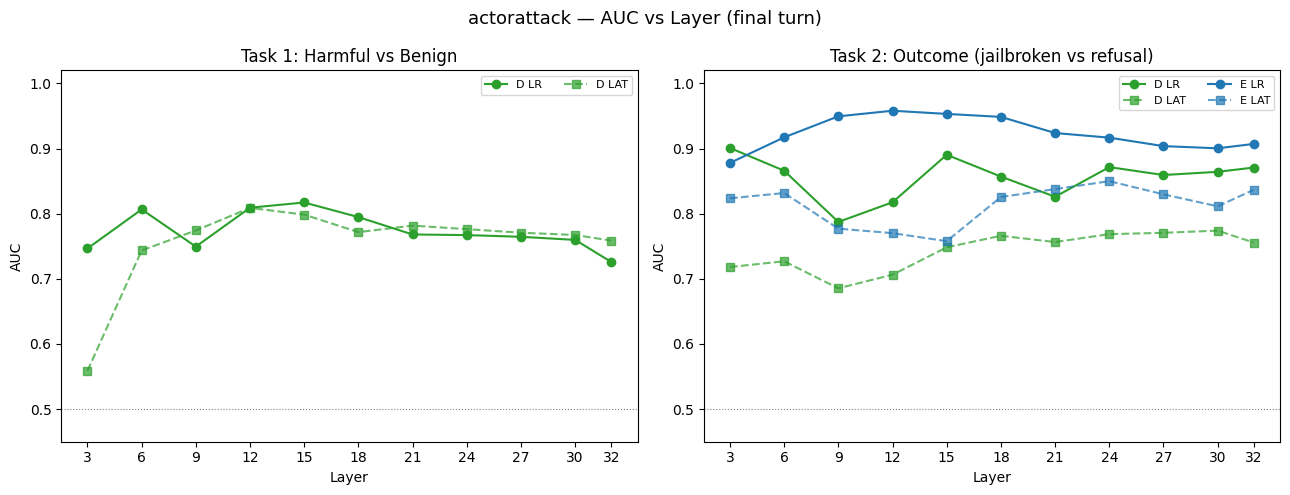

Saved → /home/lisahusieva/multi-turn-rep-eng/multi-turn-rep-eng/notebooks/figures/actorattack/08_auc_vs_layer.png


In [5]:
# ── Main plot: AUC vs layer, both tasks, all designs ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, results, title in zip(
    axes,
    [task1_results, task2_results],
    ["Task 1: Harmful vs Benign", "Task 2: Outcome (jailbroken vs refusal)"],
):
    for design in DESIGNS:
        if design not in results:
            continue
        df = results[design]
        c  = DESIGN_COLORS[design]
        ax.plot(df["layer"], df["lr_auc"],  color=c, linestyle="-",
                marker="o", label=f"{design} LR")
        ax.plot(df["layer"], df["lat_auc"], color=c, linestyle="--",
                marker="s", alpha=0.7, label=f"{design} LAT")

    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)
    ax.set_xlabel("Layer")
    ax.set_ylabel("AUC")
    ax.set_title(title)
    ax.set_xticks(LAYER_INDICES)
    ax.set_ylim(0.45, 1.02)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle(f"{FRAMEWORK} — AUC vs Layer (final turn)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_auc_vs_layer.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / '08_auc_vs_layer.png'}")

## Design E vs F: contextual contribution per layer

E has full prior context; F has prior assistant responses masked.
The gap `AUC(E) − AUC(F)` shows at which layer prior compliant responses start contributing.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, results, title, ytitle in zip(
    axes,
    [task1_results, task2_results],
    ["Task 1: Harmful vs Benign", "Task 2: Outcome probe"],
    ["AUC(E) − AUC(F)", "AUC(E) − AUC(F)"],
):
    if "E" not in results or "F" not in results:
        ax.set_title(f"{title} — missing data")
        continue

    df_e = results["E"].set_index("layer")
    df_f = results["F"].set_index("layer")
    common = df_e.index.intersection(df_f.index)

    delta_lr  = df_e.loc[common, "lr_auc"]  - df_f.loc[common, "lr_auc"]
    delta_lat = df_e.loc[common, "lat_auc"] - df_f.loc[common, "lat_auc"]

    ax.plot(common, delta_lr,  color="steelblue",  marker="o", label="LR")
    ax.plot(common, delta_lat, color="darkorange", marker="s", label="LAT")
    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_xlabel("Layer")
    ax.set_ylabel(ytitle)
    ax.set_title(title)
    ax.set_xticks(list(common))
    ax.legend(fontsize=9)

fig.suptitle(f"{FRAMEWORK} — Contextual contribution: AUC(E) − AUC(F) per layer", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_ef_delta.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / '08_ef_delta.png'}")

## Turn × Layer heatmap (Design E, Task 2)

LR AUC at every (turn, layer) combination. Shows whether the layer profile shifts as the conversation unfolds.

In [ ]:
sh, mh = load_layersweep(HARMFUL_FOLDER, "E")
if sh is None:
    print("Design E harmful data not found.")
else:
    keep = mh["verdict"].isin(["jailbroken", "refusal"])
    meta_h   = mh[keep].copy().reset_index(drop=True)
    states_h = sh[keep.values]
    meta_h["outcome"] = (meta_h["verdict"] == "jailbroken").astype(int)

    turn_positions = sorted(meta_h["turn_idx"].unique())

    # AUC matrix: rows = turns, cols = layers
    lr_matrix  = np.full((len(turn_positions), len(LAYER_INDICES)), np.nan)
    lat_matrix = np.full((len(turn_positions), len(LAYER_INDICES)), np.nan)

    for ti, turn in enumerate(turn_positions):
        turn_mask = meta_h["turn_idx"].values == turn
        for li, layer_num in enumerate(LAYER_INDICES):
            res = run_probes_at_layer(states_h, meta_h, li, "outcome", turn_mask)
            if res:
                lr_matrix[ti, li]  = res["lr_auc"]
                lat_matrix[ti, li] = res["lat_auc"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, mat, method in zip(axes, [lr_matrix, lat_matrix], ["LR", "LAT"]):
        im = ax.imshow(mat, vmin=0.5, vmax=1.0, cmap="RdYlGn",
                       aspect="auto", origin="upper")
        ax.set_xticks(range(len(LAYER_INDICES)))
        ax.set_xticklabels(LAYER_INDICES, fontsize=9)
        ax.set_yticks(range(len(turn_positions)))
        ax.set_yticklabels([f"Turn {t}" for t in turn_positions], fontsize=9)
        ax.set_xlabel("Layer")
        ax.set_title(f"{method} AUC")
        for ti in range(mat.shape[0]):
            for li in range(mat.shape[1]):
                v = mat[ti, li]
                if not np.isnan(v):
                    color = "white" if v > 0.85 or v < 0.58 else "black"
                    ax.text(li, ti, f"{v:.2f}", ha="center", va="center",
                            fontsize=7, color=color)
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

    fig.suptitle(f"{FRAMEWORK} — Design E, Task 2: Turn × Layer AUC heatmap", fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "08_turn_layer_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {FIG_DIR / '08_turn_layer_heatmap.png'}")